🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
---> Dung lượng ban đầu: 0.21 MB
---> Dung lượng sau khi tối ưu: 0.19 MB

2. Đang tải dữ liệu Sales...

3. Đang Melt (kéo giãn) dữ liệu Sales...

4. Đang Merge Sales với Calendar...

5. Ép cân lần cuối cho DataFrame tổng...
---> Dung lượng ban đầu: 1568.97 MB
---> Dung lượng sau khi tối ưu: 620.78 MB
-> Đang load dữ liệu Giá (sell_prices.csv)...
-> Đang hợp nhất và tính toán độ co giãn giá...
-> Đang xử lý Sự kiện lễ tết (Calendar Events)...
-> Đang tạo Đặc trưng Thời gian (Time Features)...

✅ Pipeline Dữ liệu hoàn tất! Sẵn sàng cho Machine Learning.

🎯 Đang chuẩn bị dữ liệu cho sản phẩm: 1437 tại 0

🧠 Đang khởi động hệ thống ML Routing...
-> Phân loại: Intermittent (Ngắt quãng) | Điều hướng: LightGBM Tweedie.
Đang huấn luyện AI...

🔮 Đang chạy thuật toán Dự báo Cuốn chiếu (Recursive Forecasting) cho 28 ngày TƯƠNG LAI...
✅ Đã tạo ra chuỗi thời gian hoàn toàn mới cho tương lai!

Đang chạy hàng ngàn kịch bản Mô

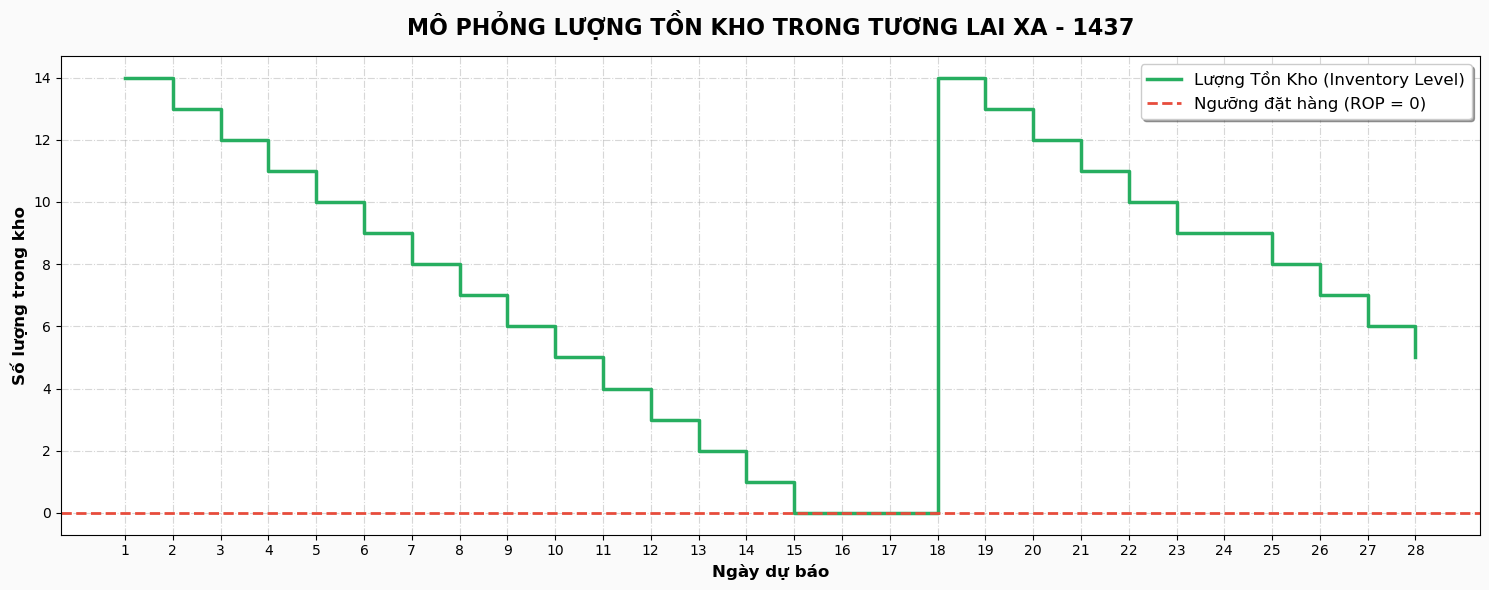

In [4]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để gọi các hàm đã đóng gói trong thư mục src
sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features, create_lag_features_for_item

RAW_DIR = '../dataset/raw/'

# ==========================================
# BƯỚC 1 & 2: TIỀN XỬ LÝ & TRÍCH XUẤT ĐẶC TRƯNG
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
df_master = load_and_preprocess_raw(RAW_DIR, nrows=10000)
df_featured = generate_all_features(df_master, RAW_DIR)
print("\n✅ Pipeline Dữ liệu hoàn tất! Sẵn sàng cho Machine Learning.\n")

# ==========================================
# BƯỚC 4: CHUẨN BỊ DỮ LIỆU CHO 1 SẢN PHẨM
# ==========================================
sample_item = df_featured['item_id'].iloc[0]
sample_store = df_featured['store_id'].iloc[0]
print(f"🎯 Đang chuẩn bị dữ liệu cho sản phẩm: {sample_item} tại {sample_store}")

df_item = df_featured[(df_featured['item_id'] == sample_item) & (df_featured['store_id'] == sample_store)].copy()
df_item = create_lag_features_for_item(df_item)

# Chia tập Train (Dùng toàn bộ lịch sử để Train cho khỏe nhất)
features = [
    'day', 'is_weekend', 'sell_price', 'price_discount', 'price_momentum',
    'event_name_1', 'lag_7', 'lag_14', 'rolling_mean_7'
]
target = 'demand'

X_train, y_train = df_item[features], df_item[target]

# ==========================================
# BƯỚC 5: ĐIỀU HƯỚNG MÔ HÌNH (ML ROUTING) & HUẤN LUYỆN
# ==========================================
print("\n🧠 Đang khởi động hệ thống ML Routing...")
item_category = 'Intermittent (Ngắt quãng)'

params = {'metric': 'rmse', 'learning_rate': 0.05, 'num_leaves': 31, 'verbose': -1, 'force_col_wise': True}

if 'Smooth' in item_category or 'Erratic' in item_category:
    print(f"-> Phân loại: {item_category} | Điều hướng: LightGBM Regression.")
    params['objective'] = 'regression'
else:
    print(f"-> Phân loại: {item_category} | Điều hướng: LightGBM Tweedie.")
    params['objective'] = 'tweedie'
    params['tweedie_variance_power'] = 1.1

categorical_features = ['event_name_1']
train_set = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)

print("Đang huấn luyện AI...")
model = lgb.train(params, train_set, num_boost_round=100) # Train trên toàn bộ dữ liệu

# ==========================================
# [TÍNH NĂNG MỚI] BƯỚC 5B: RECURSIVE FORECASTING (DỰ BÁO CUỐN CHIẾU)
# "Lấy dữ liệu đã dự đoán để dự đoán những ngày xa hơn"
# ==========================================
print("\n🔮 Đang chạy thuật toán Dự báo Cuốn chiếu (Recursive Forecasting) cho 28 ngày TƯƠNG LAI...")

future_horizon = 28
history_df = df_item.copy()
last_row = history_df.iloc[-1] # Lấy thông tin ngày cuối cùng làm cơ sở
future_predictions = []
future_dates = []

for i in range(1, future_horizon + 1):
    next_date = last_row['date'] + pd.Timedelta(days=i)
    current_demands = history_df['demand'].values
    
    # Tính toán ĐỘNG (Dynamic) các đặc trưng trễ từ chính lịch sử đã được mix với dự báo
    lag_7 = current_demands[-7]
    lag_14 = current_demands[-14]
    rolling_mean_7 = np.mean(current_demands[-7:])
    
    # Tạo row dữ liệu cho TƯƠNG LAI
    new_features = pd.DataFrame([{
        'day': next_date.day,
        'is_weekend': 1 if next_date.dayofweek in [5, 6] else 0,
        'sell_price': last_row['sell_price'],          # Giả định giá giữ nguyên
        'price_discount': last_row['price_discount'],  # Giả định không có đợt giảm giá mới
        'price_momentum': 1.0,                         
        'event_name_1': last_row['event_name_1'],      
        'lag_7': lag_7,
        'lag_14': lag_14,
        'rolling_mean_7': rolling_mean_7
    }])
    
    # AI Dự báo cho ngày Tương lai này
    pred_demand = max(0, model.predict(new_features)[0]) # Không cho phép nhu cầu âm
    future_predictions.append(pred_demand)
    future_dates.append(next_date)
    
    # CẬP NHẬT LỊCH SỬ: Nạp kết quả vừa dự báo vào kho để làm gốc cho vòng lặp ngày mai
    new_row = pd.DataFrame({'date': [next_date], 'demand': [pred_demand]})
    history_df = pd.concat([history_df, new_row], ignore_index=True)

print("✅ Đã tạo ra chuỗi thời gian hoàn toàn mới cho tương lai!")

# ==========================================
# BƯỚC 6 & 7: MÔ PHỎNG TỒN KHO & TÌM EOQ, ROP TỐI ƯU
# Dùng chính dữ liệu tương lai vừa tạo ra để tính Tối ưu hóa nhập hàng
# ==========================================
print("\nĐang chạy hàng ngàn kịch bản Mô phỏng (Monte Carlo) để tìm ROP và EOQ tối ưu nhất...")
daily_demand_forecast = np.round(future_predictions).astype(int)

LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    inventory = INITIAL_INVENTORY
    total_holding_cost = total_stockout_cost = total_ordering_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
            
        if inventory >= demand:
            inventory -= demand
        else:
            total_stockout_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
            
        total_holding_cost += inventory * HOLDING_COST
        
        if inventory <= ROP and not order_placed:
            total_ordering_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
            
        if order_placed:
            days_to_arrival -= 1
            
        inventory_history.append(inventory)
            
    return total_holding_cost + total_stockout_cost + total_ordering_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

# Báo cáo đầu ra (Khớp Bước 7)
print("\n" + "="*60)
print("📦 BÁO CÁO HÀNH ĐỘNG (SMART INVENTORY REPORT) 📦")
print("="*60)
print(f"Mã sản phẩm: \t\t{sample_item}")
print(f"Nhóm nhu cầu: \t\t{item_category}") 
print(f"Tồn kho hiện tại: \t{INITIAL_INVENTORY} sản phẩm")
print("-" * 60)
print(f"🎯 Điểm đặt hàng lại (ROP):\t{best_ROP} sản phẩm")
print(f"📦 Số lượng cần nhập (EOQ): \t{best_Q} sản phẩm / lần đặt")
print("="*60)
print(f"💰 Tổng chi phí dự kiến (Tối ưu nhất): ${best_cost:,.2f}")
print("="*60)

# ==========================================
# VẼ BIỂU ĐỒ VÀ LƯU ẢNH TỰ ĐỘNG
# ==========================================
plt.figure(figsize=(15, 6), facecolor='#FAFAFA')

plt.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Inventory Level)')
plt.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng đặt hàng (ROP = {best_ROP})')

plt.title(f"MÔ PHỎNG LƯỢNG TỒN KHO TRONG TƯƠNG LAI XA - {sample_item}", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Ngày dự báo", fontsize=12, fontweight='bold')
plt.ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
plt.xticks(range(1, 29))
plt.grid(True, linestyle='-.', alpha=0.5)
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.tight_layout()

os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_ton_kho.png', dpi=300, bbox_inches='tight')
print("\n📸 Đã lưu ảnh biểu đồ thành công tại: ../docs/images/bieu_do_ton_kho.png")

plt.show()